In [108]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, f1_score

In [109]:
df = pd.read_csv("../dataset/protein_balanced.csv")

df.head()

,sequence,label
0,MSDQFNSREARRKANSKSSPSPKKGKKRKKGGLFKKTLFTLLILFV...,binding
1,MSEPLLHLTGISRSFTAGDREFLALKHIDLSIQAGEMVAITGASGS...,binding
2,MKVNPNNIELIISAVKEEQYPETELSEVALSGRSNVGKSTFINSMI...,binding
3,MARYDLVDRLNTTFRQMEQELAAFAAHLEQHKLLVARVFSLPEVKK...,binding
4,MFWGIEISKVPVKFTPAFDLHITTACLSAVAKDTGRNVLQVKYDGK...,binding


In [110]:
df_cnn = df.groupby("label").sample(n=5000, random_state=42)

df_cnn["label"].value_counts()

label
binding      5000
enzyme       5000
transport    5000
Name: count, dtype: int64

In [111]:
amino_acids = "ACDEFGHIKLMNPQRSTVWY"
aa_to_int = {aa: i+1 for i, aa in enumerate(amino_acids)}

MAX_LEN = 300

def encode_sequence(seq):
    seq = seq.upper()
    encoded = [aa_to_int.get(aa, 0) for aa in seq[:MAX_LEN]]
    
    if len(encoded) < MAX_LEN:
        encoded += [0] * (MAX_LEN - len(encoded))
    
    return encoded

In [112]:
X = np.array([encode_sequence(seq) for seq in df_cnn["sequence"]])

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df_cnn["label"])

print(X.shape)
print(y.shape)
print(label_encoder.classes_)

(15000, 300)
(15000,)
['binding' 'enzyme' 'transport']


In [113]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [114]:
class ProteinDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [115]:
train_dataset = ProteinDataset(X_train, y_train)
test_dataset = ProteinDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [116]:
class ImprovedProteinCNN(nn.Module):
    def __init__(self, vocab_size=21, embed_dim=128, num_classes=3):
        super(ImprovedProteinCNN, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.conv1 = nn.Conv1d(embed_dim, 128, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(128)

        self.conv2 = nn.Conv1d(128, 256, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(256)

        self.conv3 = nn.Conv1d(256, 256, kernel_size=7, padding=3)
        self.bn3 = nn.BatchNorm1d(256)

        self.pool = nn.AdaptiveMaxPool1d(1)

        self.dropout = nn.Dropout(0.5)

        self.fc1 = nn.Linear(256, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)

        x = torch.relu(self.bn1(self.conv1(x)))
        x = torch.relu(self.bn2(self.conv2(x)))
        x = torch.relu(self.bn3(self.conv3(x)))

        x = self.pool(x).squeeze(-1)

        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

In [119]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model_cnn = ImprovedProteinCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=0.0005)

EPOCHS = 5

for epoch in range(EPOCHS):
    model_cnn.train()
    total_loss = 0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model_cnn(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {total_loss/len(train_loader):.4f}")

Using device: cpu
Epoch [1/5], Loss: 0.7219
Epoch [2/5], Loss: 0.4365
Epoch [3/5], Loss: 0.2919
Epoch [4/5], Loss: 0.1909
Epoch [5/5], Loss: 0.1299


In [120]:
model_cnn.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)

        outputs = model_cnn(batch_X)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(batch_y.numpy())

accuracy = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average="weighted")

print("Improved CNN Accuracy:", accuracy)
print("Improved CNN Weighted F1:", f1)

print(classification_report(
    all_labels,
    all_preds,
    target_names=label_encoder.classes_
))

Improved CNN Accuracy: 0.8463333333333334
Improved CNN Weighted F1: 0.8472214966324402
              precision    recall  f1-score   support

     binding       0.97      0.78      0.86      1000
      enzyme       0.92      0.78      0.84      1000
   transport       0.73      0.98      0.84      1000

    accuracy                           0.85      3000
   macro avg       0.87      0.85      0.85      3000
weighted avg       0.87      0.85      0.85      3000



In [79]:
torch.save(model_cnn.state_dict(), "../models/cnn_model.pth")

In [75]:
import pandas as pd

comparison = {
    "Model": [
        "TF-IDF + Logistic Regression",
        "TF-IDF + Random Forest",
        "TF-IDF + SVM",

        "1D CNN (5 Epochs, 15000)",
        "1D CNN (5 Epochs, 21000)",
        "1D CNN (15 Epochs, 15000)",

        "ESM + SVC (1500)",
        "ESM + SVC (9000)",
        "ESM + SVC (15000)"
    ],

    "Accuracy": [
        0.90,
        0.88,
        0.91,

        0.83,
        0.86,
        0.91,

        0.88,
        0.93,
        0.94
    ],

    "Category": [
        "Classical ML",
        "Classical ML",
        "Classical ML",

        "Deep Learning",
        "Deep Learning",
        "Deep Learning",

        "Transformer Embedding",
        "Transformer Embedding",
        "Transformer Embedding"
    ]
}

df_compare = pd.DataFrame(comparison)

# Sort by accuracy
df_compare = df_compare.sort_values(by="Accuracy", ascending=True)

df_compare

,Model,Accuracy,Category
3,"1D CNN (5 Epochs, 15000)",0.83,Deep Learning
4,"1D CNN (5 Epochs, 21000)",0.86,Deep Learning
6,ESM + SVC (1500),0.88,Transformer Embedding
1,TF-IDF + Random Forest,0.88,Classical ML
0,TF-IDF + Logistic Regression,0.90,Classical ML
2,TF-IDF + SVM,0.91,Classical ML
5,"1D CNN (15 Epochs, 15000)",0.91,Deep Learning
7,ESM + SVC (9000),0.93,Transformer Embedding
8,ESM + SVC (15000),0.94,Transformer Embedding


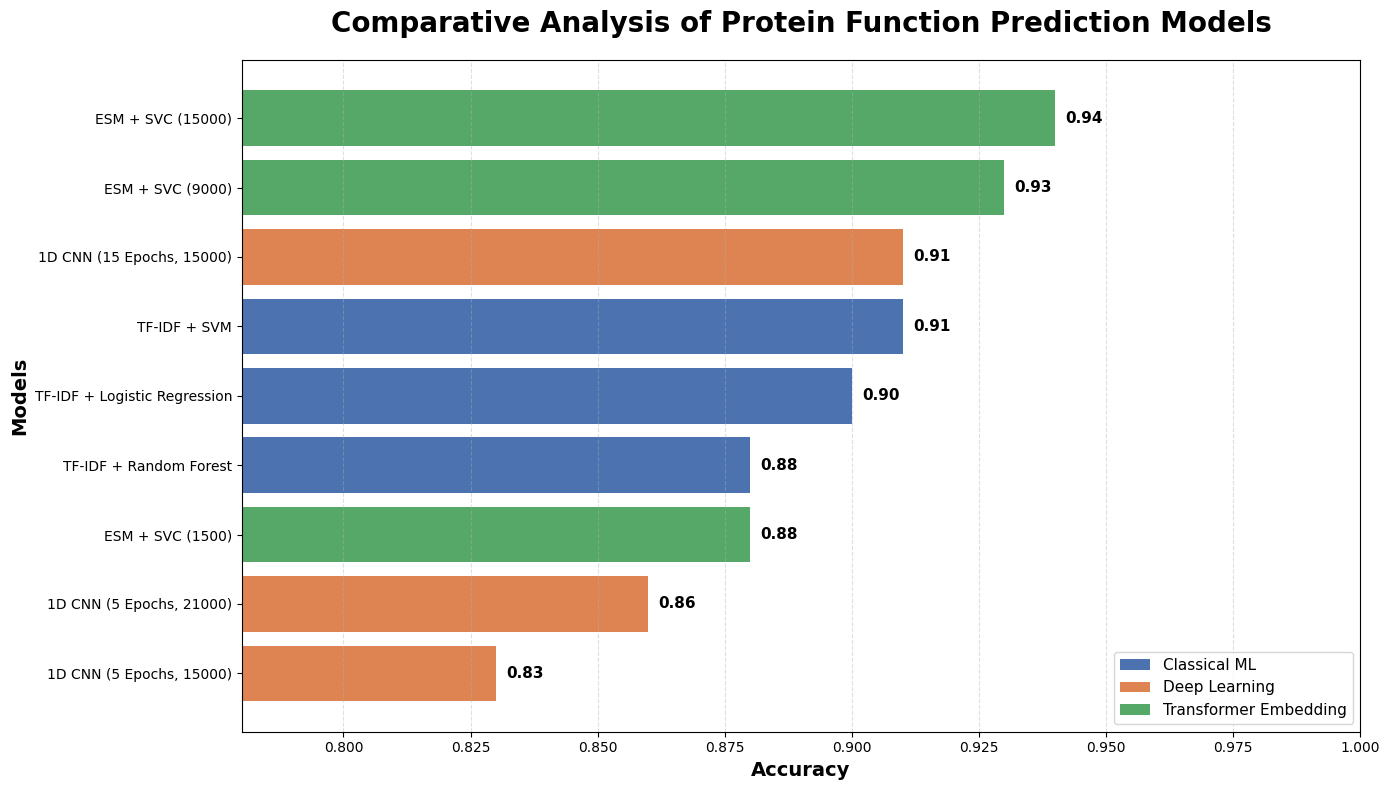

In [76]:
import matplotlib.pyplot as plt
import numpy as np

# Colors based on category
colors = []

for cat in df_compare["Category"]:
    if cat == "Classical ML":
        colors.append("#4C72B0")   # blue
    elif cat == "Deep Learning":
        colors.append("#DD8452")   # orange
    else:
        colors.append("#55A868")   # green

plt.figure(figsize=(14,8))

bars = plt.barh(
    df_compare["Model"],
    df_compare["Accuracy"],
    color=colors
)

# Accuracy labels
for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.002,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va='center',
        fontsize=11,
        fontweight='bold'
    )

# Title and labels
plt.title(
    "Comparative Analysis of Protein Function Prediction Models",
    fontsize=20,
    fontweight='bold',
    pad=20
)

plt.xlabel(
    "Accuracy",
    fontsize=14,
    fontweight='bold'
)

plt.ylabel(
    "Models",
    fontsize=14,
    fontweight='bold'
)

# Grid
plt.grid(axis='x', linestyle='--', alpha=0.4)

# Accuracy range
plt.xlim(0.78, 1.00)

# Legend
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor="#4C72B0", label='Classical ML'),
    Patch(facecolor="#DD8452", label='Deep Learning'),
    Patch(facecolor="#55A868", label='Transformer Embedding')
]

plt.legend(
    handles=legend_elements,
    loc='lower right',
    fontsize=11
)

plt.tight_layout()

plt.show()

# How dataset size affects 1D CNN accuracy.
# Train CNN on different sample size

In [22]:
df_cnn = df.groupby("label").sample(n=3000, random_state=42)

df_cnn["label"].value_counts()

label
binding      3000
enzyme       3000
transport    3000
Name: count, dtype: int64

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model_cnn = ImprovedProteinCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=0.0005)

EPOCHS = 5

for epoch in range(EPOCHS):
    model_cnn.train()
    total_loss = 0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model_cnn(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {total_loss/len(train_loader):.4f}")

Using device: cpu
Epoch [1/5], Loss: 0.8105
Epoch [2/5], Loss: 0.5210
Epoch [3/5], Loss: 0.3685
Epoch [4/5], Loss: 0.2636
Epoch [5/5], Loss: 0.1819


In [30]:
model_cnn.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)

        outputs = model_cnn(batch_X)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(batch_y.numpy())

accuracy = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average="weighted")

print("Improved CNN Accuracy:", accuracy)
print("Improved CNN Weighted F1:", f1)

print(classification_report(
    all_labels,
    all_preds,
    target_names=label_encoder.classes_
))

Improved CNN Accuracy: 0.8827777777777778
Improved CNN Weighted F1: 0.8828734832318234
              precision    recall  f1-score   support

     binding       0.92      0.85      0.88       600
      enzyme       0.92      0.85      0.88       600
   transport       0.82      0.95      0.88       600

    accuracy                           0.88      1800
   macro avg       0.89      0.88      0.88      1800
weighted avg       0.89      0.88      0.88      1800



In [31]:
df_cnn = df.groupby("label").sample(n=2000, random_state=42)

df_cnn["label"].value_counts()

label
binding      2000
enzyme       2000
transport    2000
Name: count, dtype: int64

In [39]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model_cnn = ImprovedProteinCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=0.0005)

EPOCHS = 5

for epoch in range(EPOCHS):
    model_cnn.train()
    total_loss = 0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model_cnn(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {total_loss/len(train_loader):.4f}")

Using device: cpu
Epoch [1/5], Loss: 0.8662
Epoch [2/5], Loss: 0.5685
Epoch [3/5], Loss: 0.4098
Epoch [4/5], Loss: 0.2906
Epoch [5/5], Loss: 0.1872


In [40]:
model_cnn.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)

        outputs = model_cnn(batch_X)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(batch_y.numpy())

accuracy = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average="weighted")

print("Improved CNN Accuracy:", accuracy)
print("Improved CNN Weighted F1:", f1)

print(classification_report(
    all_labels,
    all_preds,
    target_names=label_encoder.classes_
))

Improved CNN Accuracy: 0.85
Improved CNN Weighted F1: 0.8502531470590576
              precision    recall  f1-score   support

     binding       0.85      0.87      0.86       400
      enzyme       0.79      0.89      0.84       400
   transport       0.92      0.79      0.85       400

    accuracy                           0.85      1200
   macro avg       0.86      0.85      0.85      1200
weighted avg       0.86      0.85      0.85      1200



In [41]:
df_cnn = df.groupby("label").sample(n=1000, random_state=42)

df_cnn["label"].value_counts()

label
binding      1000
enzyme       1000
transport    1000
Name: count, dtype: int64

In [48]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model_cnn = ImprovedProteinCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=0.0005)

EPOCHS = 5

for epoch in range(EPOCHS):
    model_cnn.train()
    total_loss = 0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model_cnn(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {total_loss/len(train_loader):.4f}")

Using device: cpu
Epoch [1/5], Loss: 0.9689
Epoch [2/5], Loss: 0.7112
Epoch [3/5], Loss: 0.5307
Epoch [4/5], Loss: 0.3692
Epoch [5/5], Loss: 0.2387


In [49]:
model_cnn.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)

        outputs = model_cnn(batch_X)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(batch_y.numpy())

accuracy = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average="weighted")

print("Improved CNN Accuracy:", accuracy)
print("Improved CNN Weighted F1:", f1)

print(classification_report(
    all_labels,
    all_preds,
    target_names=label_encoder.classes_
))

Improved CNN Accuracy: 0.8
Improved CNN Weighted F1: 0.8004783289172424
              precision    recall  f1-score   support

     binding       0.81      0.80      0.80       200
      enzyme       0.75      0.81      0.78       200
   transport       0.85      0.79      0.82       200

    accuracy                           0.80       600
   macro avg       0.80      0.80      0.80       600
weighted avg       0.80      0.80      0.80       600



In [54]:
import pandas as pd

scaling_results = {
    "Dataset Size": [3000, 6000, 9000, 15000, 21000],
    "Samples per Class": [1000, 2000, 3000, 5000, 7000],
    "Epochs": [5, 5, 5, 5, 5],
    "CNN Accuracy": [0.80, 0.85, 0.88, 0.83, 0.86]
}

df_scaling = pd.DataFrame(scaling_results)
df_scaling

,Dataset Size,Samples per Class,Epochs,CNN Accuracy
0,3000,1000,5,0.80
1,6000,2000,5,0.85
2,9000,3000,5,0.88
3,15000,5000,5,0.83
4,21000,7000,5,0.86


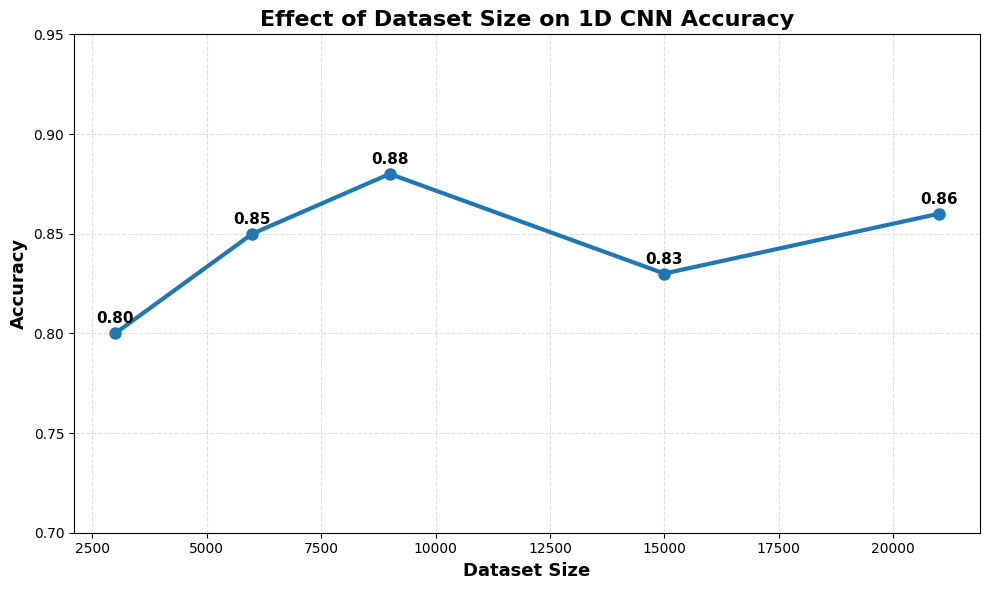

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    df_scaling["Dataset Size"],
    df_scaling["CNN Accuracy"],
    marker="o",
    linewidth=3,
    markersize=8
)

for x, y in zip(df_scaling["Dataset Size"], df_scaling["CNN Accuracy"]):
    plt.text(x, y + 0.005, f"{y:.2f}", ha="center", fontsize=11, fontweight="bold")

plt.title("Effect of Dataset Size on 1D CNN Accuracy", fontsize=16, fontweight="bold")
plt.xlabel("Dataset Size", fontsize=13, fontweight="bold")
plt.ylabel("Accuracy", fontsize=13, fontweight="bold")

plt.grid(True, linestyle="--", alpha=0.4)
plt.ylim(0.70, 0.95)

plt.tight_layout()
plt.show()

# Epoch Effect
# Train CNN on different epochs on sample size =15000

In [58]:
df_cnn = df.groupby("label").sample(n=5000, random_state=42)

df_cnn["label"].value_counts()

label
binding      5000
enzyme       5000
transport    5000
Name: count, dtype: int64

In [65]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model_cnn = ImprovedProteinCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=0.0005)

EPOCHS = 15

for epoch in range(EPOCHS):
    model_cnn.train()
    total_loss = 0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model_cnn(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {total_loss/len(train_loader):.4f}")

Using device: cpu
Epoch [1/15], Loss: 0.7166
Epoch [2/15], Loss: 0.4260
Epoch [3/15], Loss: 0.2970
Epoch [4/15], Loss: 0.2012
Epoch [5/15], Loss: 0.1241
Epoch [6/15], Loss: 0.0699
Epoch [7/15], Loss: 0.0486
Epoch [8/15], Loss: 0.0460
Epoch [9/15], Loss: 0.0311
Epoch [10/15], Loss: 0.0279
Epoch [11/15], Loss: 0.0194
Epoch [12/15], Loss: 0.0169
Epoch [13/15], Loss: 0.0223
Epoch [14/15], Loss: 0.0121
Epoch [15/15], Loss: 0.0184


In [66]:
model_cnn.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)

        outputs = model_cnn(batch_X)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(batch_y.numpy())

accuracy = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average="weighted")

print("Improved CNN Accuracy:", accuracy)
print("Improved CNN Weighted F1:", f1)

print(classification_report(
    all_labels,
    all_preds,
    target_names=label_encoder.classes_
))

Improved CNN Accuracy: 0.904
Improved CNN Weighted F1: 0.9043481388268068
              precision    recall  f1-score   support

     binding       0.90      0.91      0.91      1000
      enzyme       0.86      0.93      0.89      1000
   transport       0.96      0.87      0.92      1000

    accuracy                           0.90      3000
   macro avg       0.91      0.90      0.90      3000
weighted avg       0.91      0.90      0.90      3000



In [77]:
df_cnn = df.groupby("label").sample(n=5000, random_state=42)

df_cnn["label"].value_counts()

label
binding      5000
enzyme       5000
transport    5000
Name: count, dtype: int64

In [84]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model_cnn = ImprovedProteinCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=0.0005)

EPOCHS = 10

for epoch in range(EPOCHS):
    model_cnn.train()
    total_loss = 0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model_cnn(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {total_loss/len(train_loader):.4f}")

Using device: cpu
Epoch [1/10], Loss: 0.7143
Epoch [2/10], Loss: 0.4334
Epoch [3/10], Loss: 0.3003
Epoch [4/10], Loss: 0.1946
Epoch [5/10], Loss: 0.1215
Epoch [6/10], Loss: 0.0708
Epoch [7/10], Loss: 0.0444
Epoch [8/10], Loss: 0.0361
Epoch [9/10], Loss: 0.0190
Epoch [10/10], Loss: 0.0188


In [85]:
model_cnn.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)

        outputs = model_cnn(batch_X)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(batch_y.numpy())

accuracy = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average="weighted")

print("Improved CNN Accuracy:", accuracy)
print("Improved CNN Weighted F1:", f1)

print(classification_report(
    all_labels,
    all_preds,
    target_names=label_encoder.classes_
))

Improved CNN Accuracy: 0.91
Improved CNN Weighted F1: 0.9099981964840217
              precision    recall  f1-score   support

     binding       0.96      0.86      0.91      1000
      enzyme       0.88      0.93      0.90      1000
   transport       0.91      0.94      0.92      1000

    accuracy                           0.91      3000
   macro avg       0.91      0.91      0.91      3000
weighted avg       0.91      0.91      0.91      3000



In [121]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model_cnn = ImprovedProteinCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=0.0005)

EPOCHS = 5

for epoch in range(EPOCHS):
    model_cnn.train()
    total_loss = 0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model_cnn(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {total_loss/len(train_loader):.4f}")

Using device: cpu
Epoch [1/5], Loss: 0.6947
Epoch [2/5], Loss: 0.4304
Epoch [3/5], Loss: 0.3042
Epoch [4/5], Loss: 0.2138
Epoch [5/5], Loss: 0.1316


In [122]:
model_cnn.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)

        outputs = model_cnn(batch_X)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(batch_y.numpy())

accuracy = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average="weighted")

print("Improved CNN Accuracy:", accuracy)
print("Improved CNN Weighted F1:", f1)

print(classification_report(
    all_labels,
    all_preds,
    target_names=label_encoder.classes_
))

Improved CNN Accuracy: 0.894
Improved CNN Weighted F1: 0.8937691821719136
              precision    recall  f1-score   support

     binding       0.93      0.88      0.90      1000
      enzyme       0.91      0.85      0.88      1000
   transport       0.85      0.95      0.90      1000

    accuracy                           0.89      3000
   macro avg       0.90      0.89      0.89      3000
weighted avg       0.90      0.89      0.89      3000



In [123]:
import pandas as pd

epoch_results = {
    "Dataset Size": [15000, 15000, 15000],
    "Epochs": [5, 10, 15],
    "CNN Accuracy": [0.89, 0.91, 0.90]
}

df_epochs = pd.DataFrame(epoch_results)

df_epochs

,Dataset Size,Epochs,CNN Accuracy
0,15000,5,0.89
1,15000,10,0.91
2,15000,15,0.90


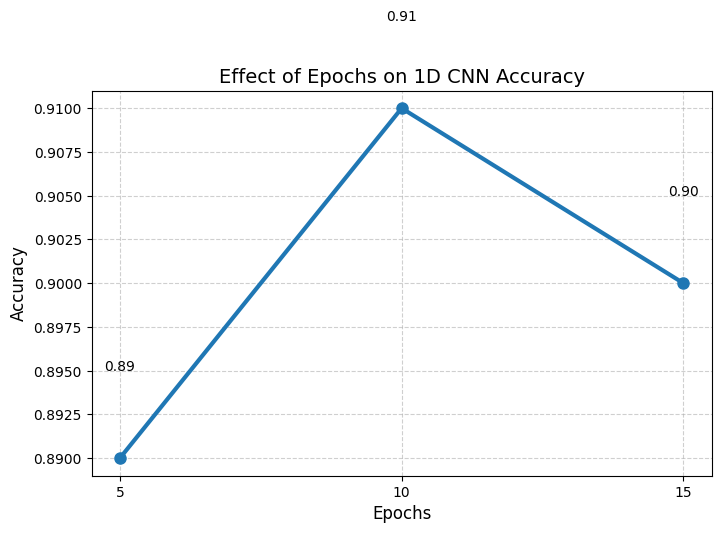

In [124]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    df_epochs["Epochs"],
    df_epochs["CNN Accuracy"],
    marker='o',
    linewidth=3,
    markersize=8
)

plt.title("Effect of Epochs on 1D CNN Accuracy", fontsize=14)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)

plt.xticks([5,10,15])

plt.grid(True, linestyle="--", alpha=0.6)

for x, y in zip(df_epochs["Epochs"], df_epochs["CNN Accuracy"]):
    plt.text(x, y+0.005, f"{y:.2f}", ha='center')

plt.show()

In [127]:
import os
os.makedirs("../results", exist_ok=True)
plt.savefig("../results/cnn_epoch_effect.png")

<Figure size 640x480 with 0 Axes>

# The experimental analysis showed that the 1D CNN model achieved rapid convergence during training. 
Accuracy increased from 0.89 at 5 epochs to 0.91 at 10 epochs, indicating improved feature learning 
with additional training iterations. However, performance slightly decreased to 0.90 at 15 epochs, 
suggesting that the model reached near-optimal convergence around 10 epochs and that further training 
provided limited performance gains.